# Gate de sobreajuste del modelo fiel al paper

Este notebook ejecuta la primera optimización completa del modelo reconstruido. La pregunta es deliberadamente limitada: **¿puede la implementación reducir el error predictivo sobre un único batch balanceado sin que la representación colapse por completo?**

No es una reproducción de los resultados del paper ni una medición de generalización. La configuración y los criterios fueron congelados antes de observar esta corrida en `configs/paper_overfit_smoke.yaml`.

## Protocolo y criterios previos

Usamos una secuencia por cada uno de los 18 regímenes, las 18 juntas en un batch fijo, encoder `direct`, predictor lineal identidad y la normalización literal por secuencia. La condición local usa AdamW durante 100 pasos; el paper no publica optimizer ni learning rate, de modo que estos valores son sólo un instrumento de desarrollo.

El gate exige valores finitos, loss final media no mayor al 25% de la inicial, al menos 10% de la dispersión inicial y rango efectivo final de al menos 2. Con 18 ejemplos centrados, el rango efectivo máximo observable es 17, aunque el latente tenga 32 coordenadas.

In [1]:
# ruff: noqa: E402, E501
import json
import platform
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "No se encontró la raíz del repositorio."
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader

from koopman_jepa.paper_config import load_paper_experiment_config
from koopman_jepa.paper_data import (
    PAPER_REGIME_NAMES,
    PaperRegimeDataset,
    generate_paper_master,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_overfit_gate,
    make_paper_optimizer,
    overfit_fixed_batch,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

Python: 3.13.12
NumPy: 2.5.3
PyTorch: 2.14.0


In [2]:
config_path = ROOT / "configs" / "paper_overfit_smoke.yaml"
config = load_paper_experiment_config(config_path)

random.seed(config.optimization.seed)
np.random.seed(config.optimization.seed)
torch.manual_seed(config.optimization.seed)
torch.use_deterministic_algorithms(True)

print(config_path.relative_to(ROOT))
print(json.dumps(asdict(config), indent=2))

configs/paper_overfit_smoke.yaml
{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 1,
    "val_per_regime": 1,
    "test_per_regime": 1,
    "base_seed": 0,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "linear",
    "linear_initialization": "identity",
    "mlp_depth": "two_hidden",
    "ema_decay": 0.996
  },
  "optimization": {
    "optimizer": "adamw",
    "learning_rate": 0.001,
    "weight_decay": 0.0,
    "batch_size": 18,
    "steps": 100,
    "seed": 0,
    "device": "cpu"
  },
  "gate": {
    "comparison_window": 10,
    "max_loss_ratio": 0.25,
    "min_embedding_std_ratio": 0.1,
    "min_effective_rank": 2.0
  }
}


## Batch fijo

No hay muestreo repetido ni shuffle: la única secuencia de cada régimen aparece exactamente una vez. Esto evita que un gate mecánico pase por una composición accidentalmente fácil del batch.

In [3]:
dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
loader = DataLoader(dataset, batch_size=config.optimization.batch_size, shuffle=False)
context, target, labels = next(iter(loader))
expected_labels = torch.arange(len(PAPER_REGIME_NAMES))

assert len(dataset) == config.optimization.batch_size == len(PAPER_REGIME_NAMES)
assert torch.equal(labels, expected_labels)
assert context.shape == target.shape == (18, 1, 768)
assert torch.isfinite(context).all() and torch.isfinite(target).all()

print(f"Dataset: {len(dataset)} ejemplos")
print(f"Context/target: {tuple(context.shape)}")
print(f"Etiquetas: {labels.tolist()}")
print("Cada régimen aparece exactamente una vez: PASS")

Dataset: 18 ejemplos
Context/target: (18, 1, 768)
Etiquetas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Cada régimen aparece exactamente una vez: PASS


## Optimización

Cada registro se mide antes de la actualización de ese paso. Después del `optimizer.step()`, el target encoder se mueve con EMA `0.996 / 0.004`. Además de la loss guardamos normas de gradiente, dispersión media del embedding y rango efectivo.

In [4]:
device = torch.device(config.optimization.device)
model = PaperTemporalJEPA(config.model).to(device)
optimizer = make_paper_optimizer(model, config.optimization)
context = context.to(device)
target = target.to(device)

trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
frozen_parameters = sum(parameter.numel() for parameter in model.parameters() if not parameter.requires_grad)

started = time.perf_counter()
history = overfit_fixed_batch(model, context, target, optimizer, config.optimization)
elapsed = time.perf_counter() - started
gate = evaluate_overfit_gate(history, config.gate)

print(f"Parámetros entrenables: {trainable_parameters:,}")
print(f"Parámetros target congelados: {frozen_parameters:,}")
print(f"Tiempo de 100 pasos: {elapsed:.2f} s")
print(json.dumps(asdict(gate), indent=2))

Parámetros entrenables: 231,296
Parámetros target congelados: 230,272
Tiempo de 100 pasos: 1.48 s
{
  "all_finite": true,
  "initial_loss": 0.11084026163443923,
  "final_loss": 2.7975103876087815e-05,
  "loss_ratio": 0.00025239117504388545,
  "initial_embedding_std": 0.006355596240609884,
  "final_embedding_std": 0.006300071347504854,
  "embedding_std_ratio": 0.9912636216960657,
  "final_effective_rank": 12.078023052215576,
  "loss_passed": true,
  "spread_passed": true,
  "rank_passed": true,
  "passed": true
}


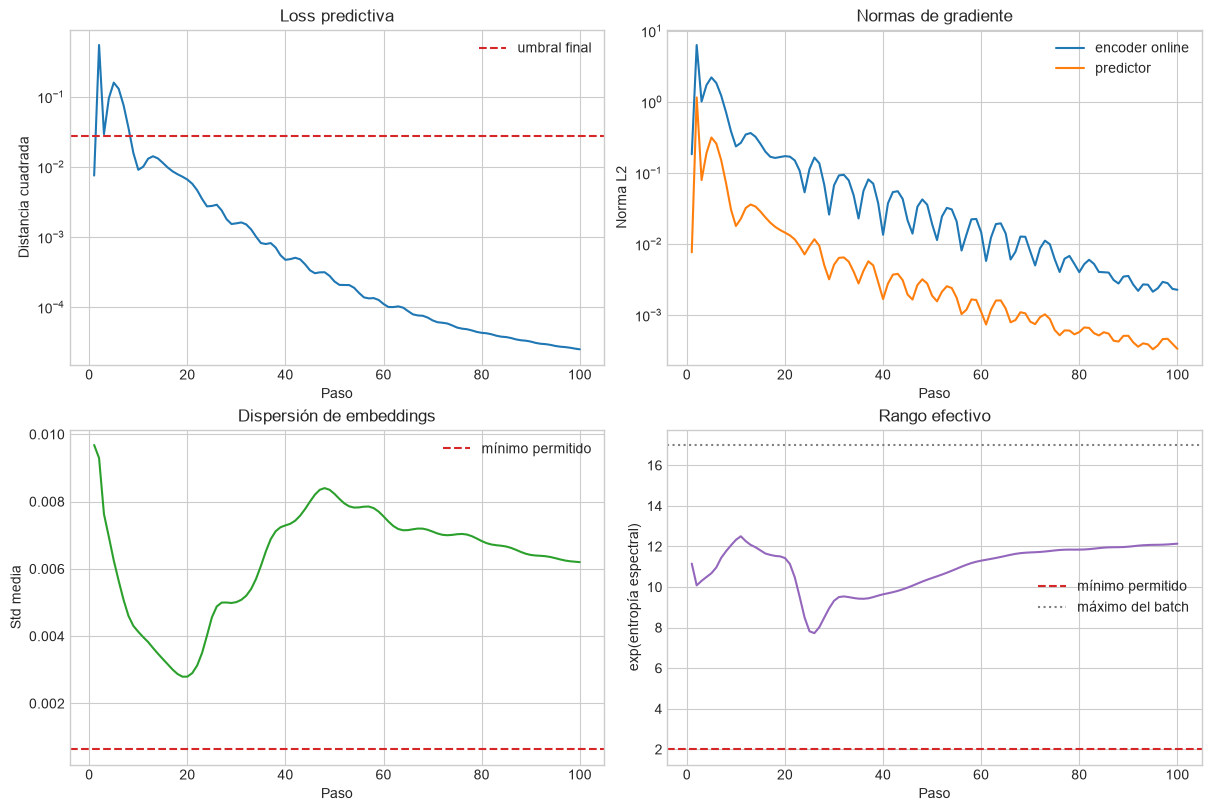

In [5]:
steps = np.arange(1, len(history) + 1)
losses = np.array([row.loss for row in history])
online_gradients = np.array([row.online_gradient_norm for row in history])
predictor_gradients = np.array([row.predictor_gradient_norm for row in history])
embedding_std = np.array([row.embedding_std_mean for row in history])
effective_rank = np.array([row.effective_rank for row in history])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].semilogy(steps, np.maximum(losses, 1e-12), color="tab:blue")
axes[0, 0].axhline(gate.initial_loss * config.gate.max_loss_ratio, color="tab:red", linestyle="--", label="umbral final")
axes[0, 0].set(title="Loss predictiva", xlabel="Paso", ylabel="Distancia cuadrada")
axes[0, 0].legend()

axes[0, 1].semilogy(steps, np.maximum(online_gradients, 1e-12), label="encoder online")
axes[0, 1].semilogy(steps, np.maximum(predictor_gradients, 1e-12), label="predictor")
axes[0, 1].set(title="Normas de gradiente", xlabel="Paso", ylabel="Norma L2")
axes[0, 1].legend()

axes[1, 0].plot(steps, embedding_std, color="tab:green")
axes[1, 0].axhline(gate.initial_embedding_std * config.gate.min_embedding_std_ratio, color="tab:red", linestyle="--", label="mínimo permitido")
axes[1, 0].set(title="Dispersión de embeddings", xlabel="Paso", ylabel="Std media")
axes[1, 0].legend()

axes[1, 1].plot(steps, effective_rank, color="tab:purple")
axes[1, 1].axhline(config.gate.min_effective_rank, color="tab:red", linestyle="--", label="mínimo permitido")
axes[1, 1].axhline(17, color="0.5", linestyle=":", label="máximo del batch")
axes[1, 1].set(title="Rango efectivo", xlabel="Paso", ylabel="exp(entropía espectral)")
axes[1, 1].legend()

plt.show()

In [6]:
status = "PASS" if gate.passed else "FAIL"
peak_loss_step = int(losses.argmax() + 1)
minimum_std_step = int(embedding_std.argmin() + 1)
minimum_rank_step = int(effective_rank.argmin() + 1)
final_to_first_step_loss = gate.final_loss / losses[0]
decision = (
    "El gate pasa y habilita una corrida corta con train y validation separados."
    if gate.passed
    else "El gate falla; no corresponde escalar el entrenamiento con esta configuración."
)
display(Markdown(f"""## Resultado e interpretación

- **Gate global: {status}.**
- **Optimización:** la loss media pasó de `{gate.initial_loss:.6g}` a `{gate.final_loss:.6g}`; ratio final/inicial = `{gate.loss_ratio:.6f}` (`{gate.loss_ratio:.3%}`) frente al máximo permitido `{config.gate.max_loss_ratio:.3f}`.
- **Dispersión:** la std media pasó de `{gate.initial_embedding_std:.6g}` a `{gate.final_embedding_std:.6g}`; retuvo `{gate.embedding_std_ratio:.1%}` de su valor inicial frente al mínimo `{config.gate.min_embedding_std_ratio:.1%}`.
- **Dimensionalidad:** el rango efectivo medio final fue `{gate.final_effective_rank:.3f}` frente al mínimo `{config.gate.min_effective_rank:.1f}` y al máximo algebraico 17 de este batch.
- **Estabilidad numérica:** {'PASS' if gate.all_finite else 'FAIL'}; todas las loss, normas de gradiente y métricas de representación deben ser finitas.

### Lectura de las curvas

La optimización no es monótona al comienzo: la loss alcanza un máximo de `{losses.max():.6g}` en el paso `{peak_loss_step}` y luego entra en un descenso sostenido. Como el promedio inicial incluye ese transitorio, comprobamos además que la media final es `{final_to_first_step_loss:.3%}` de la loss del primer paso. Las normas de gradiente exhiben oscilaciones decrecientes, sin explosión sostenida ni valores no finitos.

La dispersión cae temporalmente hasta `{embedding_std.min():.6g}` en el paso `{minimum_std_step}`, pero se recupera y termina cerca de su promedio inicial. El rango efectivo muestra el mismo transitorio: su mínimo es `{effective_rank.min():.3f}` en el paso `{minimum_rank_step}` y luego se recupera hasta aproximadamente 12. Esta recuperación conjunta contradice la hipótesis de colapso completo durante el smoke test, aunque no garantiza que una corrida larga sea estable.

### Qué podemos concluir

La ruta completa de datos, modelo, gradientes, optimizer y EMA pudo reducir el objetivo en una escala de memorización sin colapso completo según los umbrales predefinidos. {decision} **Esto no demuestra** separabilidad fuera de muestra, recuperación de invariantes de Koopman ni reproducción de los porcentajes publicados.
"""))

## Resultado e interpretación

- **Gate global: PASS.**
- **Optimización:** la loss media pasó de `0.11084` a `2.79751e-05`; ratio final/inicial = `0.000252` (`0.025%`) frente al máximo permitido `0.250`.
- **Dispersión:** la std media pasó de `0.0063556` a `0.00630007`; retuvo `99.1%` de su valor inicial frente al mínimo `10.0%`.
- **Dimensionalidad:** el rango efectivo medio final fue `12.078` frente al mínimo `2.0` y al máximo algebraico 17 de este batch.
- **Estabilidad numérica:** PASS; todas las loss, normas de gradiente y métricas de representación deben ser finitas.

### Lectura de las curvas

La optimización no es monótona al comienzo: la loss alcanza un máximo de `0.548645` en el paso `2` y luego entra en un descenso sostenido. Como el promedio inicial incluye ese transitorio, comprobamos además que la media final es `0.370%` de la loss del primer paso. Las normas de gradiente exhiben oscilaciones decrecientes, sin explosión sostenida ni valores no finitos.

La dispersión cae temporalmente hasta `0.00279492` en el paso `19`, pero se recupera y termina cerca de su promedio inicial. El rango efectivo muestra el mismo transitorio: su mínimo es `7.727` en el paso `26` y luego se recupera hasta aproximadamente 12. Esta recuperación conjunta contradice la hipótesis de colapso completo durante el smoke test, aunque no garantiza que una corrida larga sea estable.

### Qué podemos concluir

La ruta completa de datos, modelo, gradientes, optimizer y EMA pudo reducir el objetivo en una escala de memorización sin colapso completo según los umbrales predefinidos. El gate pasa y habilita una corrida corta con train y validation separados. **Esto no demuestra** separabilidad fuera de muestra, recuperación de invariantes de Koopman ni reproducción de los porcentajes publicados.
